# Plot correlation matrices

Group 1 and Group 2 separately

## Paths and set-up

In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from matplotlib.colors import LinearSegmentedColormap

# =============================================================================
# PATHS
# =============================================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MERGED_DATA_FILE = DATA_DIR / "merged_data.csv"

merged_df = pd.read_csv(MERGED_DATA_FILE)

print(f"Total samples in merged dataset: {merged_df.shape[0]}")

# =============================================================================
# VIRUS LABELS
# =============================================================================

virus_labels = {
    "1968_H3": "A/Memphis/1/1968 H3N2",
    "1972_H3": "A/Udorn/307/1972 H3N2",
    "1982_H3": "A/Netherlands/233/1982 H3N2",
    "1991_H3": "A/UK/261/1991 H3N2",
    "2004_H3": "A/New York/55/2004 H3N2",
    "2019_H3": "A/South Australia/34/2019 H3N2",
    "2003_H7": "A/New York/107/2003 H7N2",
    "2013_H7": "A/Shanghai/1/2013 H7N9",
    "1918_H1": "A/South Carolina/1/1918 H1N1",
    "1934_H1": "A/PR/8/1934 H1N1",
    "1977_H1": "A/USSR/90/1977 H1N1",
    "2006_H1": "A/Solomon Islands/3/2006 H1N1",
    "2018_H1": "A/Brisbane/2/2018 H1N1",
    "2004_Vietnam_H5": "A/Vietnam/1203/2004 H5N1",
    "2005_Qinghai_H5": "A/bar-headed goose/Qinghai/3/2005 H5N1",
    "2022_H5": "A/mute swan/England/117298/2022 H5N1",
    "2014_H9": "A/Hong Kong/308/2014 H9N2",
    "1966_H2": "A/England/1/1966 H2N2",
}

pastel_colors = {
    "H3N2": "#cab2d6",
    "H7N2": "#fdbf6f",
    "H7N9": "#fdbf6f",
    "H5N1": "#b2df8a",
    "H1N1": "#9ecae1",
    "H2N2": "#fb9a99",
    "H9N2": "#D3D3D3",
}

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def get_pastel_bg(text):
    """Return the background colour corresponding to a virus subtype."""

    for key, color in pastel_colors.items():
        if key in text:
            return color

    return "#ffffff"

Total samples in merged dataset: 1344


## Plot correlation matrices

### Correlation matrix functions

In [ ]:
def calculate_spearman_matrices(df, columns):
    """
    Calculate pairwise Spearman correlation coefficients and p-values.
    """

    n = len(columns)

    # Initialise empty matrices
    correlation_matrix = pd.DataFrame(
        np.zeros((n, n)),
        columns=columns,
        index=columns,
    )

    pval_matrix = pd.DataFrame(
        np.zeros((n, n)),
        columns=columns,
        index=columns,
    )
     # Calculate correlation coefficients and p values
    for i in range(n):
        for j in range(i, n):

            corr, pval = spearmanr(
                df.iloc[:, i],
                df.iloc[:, j],
            )
            # Mirrors the matrix
            correlation_matrix.iloc[i, j] = corr
            correlation_matrix.iloc[j, i] = corr 

            pval_matrix.iloc[i, j] = pval
            pval_matrix.iloc[j, i] = pval

    return correlation_matrix, pval_matrix


def wrap_labels(labels):
    """
    Put the subtype on a separate x-axis line for readability.
    """

    for label in labels:

        text = label.get_text()

        if any(
            subtype in text
            for subtype in [
                "H1N1",
                "H2N2",
                "H3N2",
                "H5N1",
                "H7N2",
                "H7N9",
                "H9N2",
            ]
        ):

            split_index = text.rfind(" ")

            if split_index != -1:
                label.set_text(
                    text[:split_index]
                    + "\n"
                    + text[split_index + 1:]
                )

    return labels


def plot_correlation_matrix(
    correlation_matrix,
    title,
    output_file,
):
    """
    Plot and save a Spearman correlation matrix.
    """

    annot_matrix = pd.DataFrame(
        "",
        index=correlation_matrix.index,
        columns=correlation_matrix.columns,
    )

    # Only the correlation coefficient is displayed in the final figure
    for i in range(len(correlation_matrix)):
        for j in range(len(correlation_matrix)):

            corr_value = correlation_matrix.iloc[i, j]

            annot_matrix.iloc[i, j] = f"{corr_value:.2f}"

    # Mask the upper triangle
    mask = np.triu(
        np.ones_like(
            correlation_matrix,
            dtype=bool,
        ),
        k=1,
    )

    # Custom colour scale for the correlation co-efficients
    custom_cmap = LinearSegmentedColormap.from_list(
        "custom_cmap",
        ["yellow", "white", "grey"],
    )

    plt.figure(figsize=(12, 8))

    ax = sns.heatmap(
        correlation_matrix,
        annot=annot_matrix,
        cmap=custom_cmap,
        fmt="",
        cbar_kws={
            "label": "Correlation Coefficient"
        },
        vmin=-1,
        vmax=1,
        mask=mask,
        annot_kws={"size": 12},
    )

    plt.title(title, fontsize=16)

    ax.tick_params(
        axis="x",
        rotation=90,
        colors="black",
    )

    ax.tick_params(
        axis="y",
        rotation=0,
        colors="black",
    )
    
    ax.set_xticklabels([
        virus_labels.get(
            label.get_text(),
            label.get_text(),
        )
        for label in ax.get_xticklabels()
    ])

    ax.set_yticklabels([
        virus_labels.get(
            label.get_text(),
            label.get_text(),
        )
        for label in ax.get_yticklabels()
    ])

    # Set tick labels to black with pastel background matching the colour scheme
    for tick_label in ax.get_xticklabels():

        tick_label.set_color("black")

        tick_label.set_bbox(
            dict(
                facecolor=get_pastel_bg(
                    tick_label.get_text()
                ),
                edgecolor="none",
                boxstyle="round,pad=0.2",
                alpha=0.2,
            )
        )

    for tick_label in ax.get_yticklabels():

        tick_label.set_color("black")

        tick_label.set_bbox(
            dict(
                facecolor=get_pastel_bg(
                    tick_label.get_text()
                ),
                edgecolor="none",
                boxstyle="round,pad=0.2",
                alpha=0.2,
            )
        )

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=90,
        ha="right",
    )

    ax.set_xticklabels(
        wrap_labels(
            ax.get_xticklabels()
        )
    )

    ax.set_yticklabels(
        wrap_labels(
            ax.get_yticklabels()
        )
    )

    plt.tight_layout()
    
    plt.savefig(
        output_file,
        format="pdf",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

## Output and save


GROUP 2 CORRELATION MATRIX
Group 2 samples tested on all viruses: 243


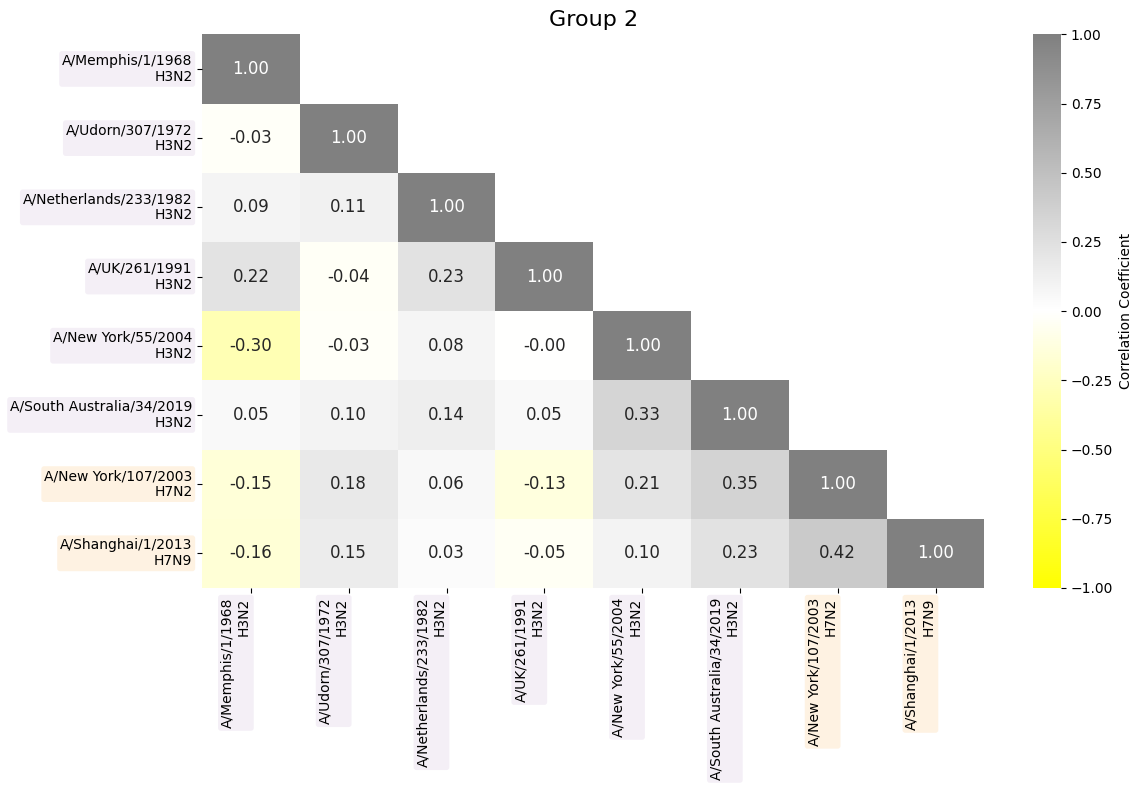


GROUP 1 CORRELATION MATRIX
Group 1 samples tested on all viruses: 188


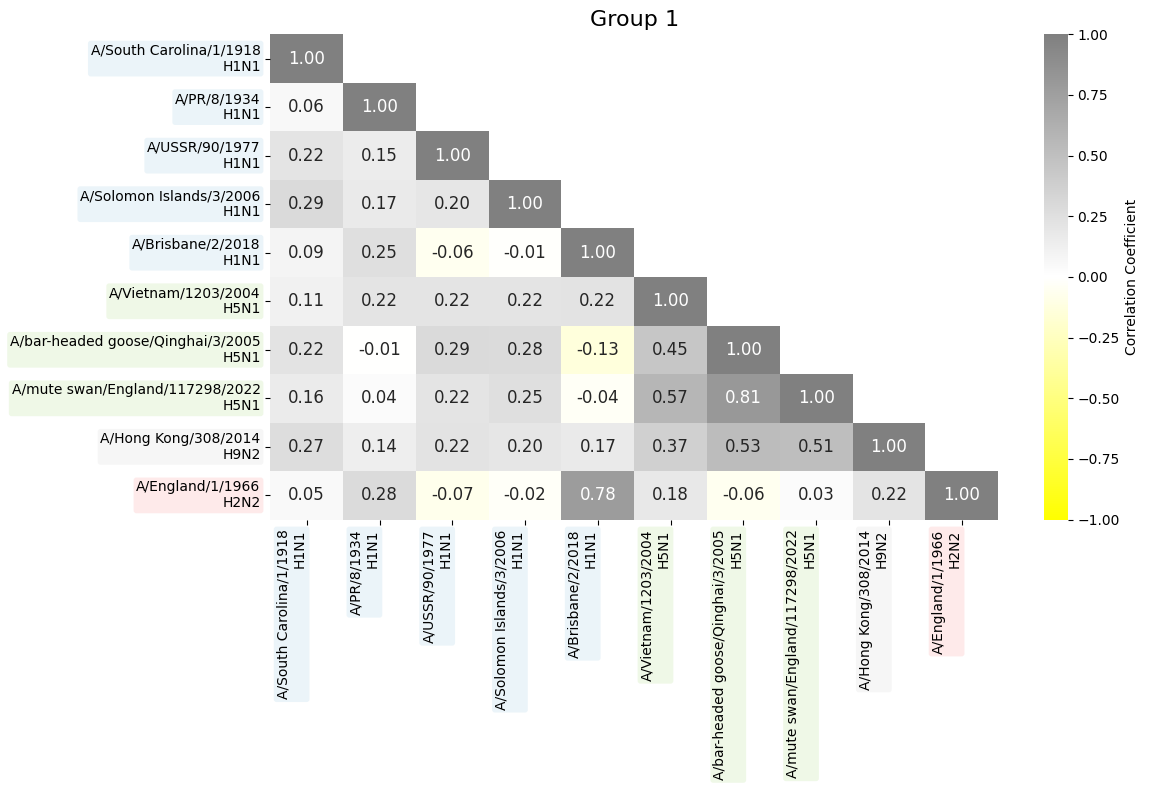

In [23]:
# =============================================================================
# GROUP 2
# =============================================================================

print("\n" + "=" * 70)
print("GROUP 2 CORRELATION MATRIX")
print("=" * 70)

# Filter to Group 2 columns
virus_columns_group2 = [
    "1968_H3",
    "1972_H3",
    "1982_H3",
    "1991_H3",
    "2004_H3",
    "2019_H3",
    "2003_H7",
    "2013_H7",
]

# Keep only samples tested on all Group 2 viruses
h3h7_cleaned = merged_df[
    virus_columns_group2
].dropna(
    how="any"
)

h3h7_cleaned = h3h7_cleaned.drop_duplicates()

print(
    f"Group 2 samples tested on all viruses: "
    f"{h3h7_cleaned.shape[0]}"
)

# Calculate Spearman correlations
correlation_matrix_group2, pval_matrix_group2 = (
    calculate_spearman_matrices(
        h3h7_cleaned,
        virus_columns_group2,
    )
)

# Plot correlation matrix
plot_correlation_matrix(
    correlation_matrix_group2,
    "Group 2",
    OUTPUT_DIR / "group2_CorrelationMatrix.pdf",
)

# =============================================================================
# GROUP 1
# =============================================================================

print("\n" + "=" * 70)
print("GROUP 1 CORRELATION MATRIX")
print("=" * 70)

# Filter to Group 1 columns
virus_columns_group1 = [
    "1918_H1",
    "1934_H1",
    "1977_H1",
    "2006_H1",
    "2018_H1",
    "2004_Vietnam_H5",
    "2005_Qinghai_H5",
    "2022_H5",
    "2014_H9",
    "1966_H2",
]

# Keep only samples tested on all Group 1 viruses
group1_cleaned = merged_df[
    virus_columns_group1
].dropna(
    how="any"
)

group1_cleaned = group1_cleaned.drop_duplicates()

print(
    f"Group 1 samples tested on all viruses: "
    f"{group1_cleaned.shape[0]}"
)

# Calculate Spearman correlations
correlation_matrix_group1, pval_matrix_group1 = (
    calculate_spearman_matrices(
        group1_cleaned,
        virus_columns_group1,
    )
)

# Plot correlation matrix
plot_correlation_matrix(
    correlation_matrix_group1,
    "Group 1",
    OUTPUT_DIR / "group1_CorrelationMatrix.pdf",
)